# 03 -  Desarrollo de Modelo Predictivo

## 1. Descripción General

En este notebook se desarrollará la fase de modelado del proyecto de predicción de precios de Airbnb. El objetivo principal de esta etapa es entrenar, evaluar y comparar distintos modelos de Machine Learning capaces de estimar el precio de una propiedad a partir de las variables seleccionadas durante los procesos de *Data Exploration* y *Feature Engineering*.

A diferencia de las etapas anteriores, donde el enfoque estuvo centrado en la comprensión de los datos, la creación de características y la selección de variables, en esta fase se trabajará sobre un dataset final (`df_model`) que ya ha sido preprocesado, transformado y validado. Esto permite concentrar el análisis exclusivamente en el desempeño de los modelos predictivos.

Para este proyecto se utilizarán tres enfoques de modelado:

- ***Linear Regression***: como modelo baseline de referencia debido a su simplicidad e interpretabilidad.
- ***Random Forest Regressor***: un modelo basado en ensambles de árboles capaz de capturar relaciones no lineales entre las variables.
- ***XGBoost Regressor***: uno de los algoritmos más utilizados en problemas de datos tabulares por su capacidad predictiva y robustez.

El proceso de modelado abarca los pasos necesarios para entrenar, evaluar y seleccionar el mejor modelo:

- División de los datos en conjuntos de entrenamiento, validación y prueba.
- Entrenamiento de los modelos candidatos con hiperparámetros iniciales.
- Evaluación de los modelos utilizando métricas de regresión apropiadas para el problema, incluyendo **R²**, **RMSE** y **MAE**.
- Optimización de hiperparámetros y comparación de resultados para seleccionar el modelo con mejor desempeño.
- Evaluación del modelo ganador sobre datos no vistos para analizar su capacidad de generalización, detectar posibles señales de sobreajuste y validar rendimiento.

Al concluir este notebook se contará con un modelo predictivo final, validado y documentado, capaz de estimar precios de propiedades Airbnb y listo para ser utilizado en futuras etapas de inferencia, despliegue y construcción de servicios de predicción.

## 2. Importación de Librerías y Carga del Dataset

In [1]:
# Import libraries and modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

# Train / validation / test split
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

# Regression metrics
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Model persistence
import joblib

# Load the final modeling dataset generated during the Feature Engineering phase.
df_model = pd.read_csv("../data/processed/df_model.csv")

# Preview first rows
df_model.head()

,calculated_host_listings_count_entire_homes_log,calculated_host_listings_count_private_rooms_log,dist_to_nearest_attraction_log,beds_log,amenity_score,accommodates_log,bedrooms_log,bathrooms_log,attractions_within_radius_log,commercial_within_radius,...,instant_bookable,has_tv,has_elevator,has_free_parking,has_coffee_maker,has_outdoor_furniture,has_air_conditioning,has_self_check_in,has_pool,log_price
0,-0.269577,0.0,1.142523,0.000000,0.143200,-0.652946,-0.563382,-0.573426,-1.147290,-1.206160,...,0,0,0,1,0,0,0,0,0,8.208764
1,0.339627,1.0,-0.314243,3.709511,0.557312,3.126331,2.973722,3.787270,0.737396,0.557533,...,0,1,0,1,1,0,0,0,0,9.798127
2,-0.269577,0.0,-0.360812,0.000000,0.521123,-0.652946,-0.563382,-0.573426,0.476090,-0.306747,...,0,1,1,0,1,0,0,1,0,6.381816
3,0.460845,0.0,0.239169,4.204426,0.673100,3.420238,2.973722,3.491134,-0.335600,-0.840773,...,0,1,0,1,1,1,0,1,0,8.208764
4,-0.730423,1.0,0.652661,0.000000,0.551671,-0.652946,-0.563382,-0.573426,-1.147290,-0.398093,...,0,1,1,0,1,0,0,0,0,5.771441


## 3. División de datos en Train / Test / Validation

Antes de entrenar los modelos, es necesario dividir el dataset en subconjuntos independientes que permitan desarrollar y evaluar los modelos de forma objetiva.

Para este proyecto se utilizará una estrategia de partición **70% / 15% / 15%**, donde cada conjunto cumple una función específica:

- **Training Set (70%):** utilizado para entrenar los modelos y aprender los patrones presentes en los datos.
- **Validation Set (15%):** utilizado para comparar modelos, optimizar hiperparámetros y evaluar su capacidad de generalización durante el desarrollo.
- **Test Set (15%):** reservado exclusivamente para la evaluación final del modelo seleccionado, proporcionando una estimación imparcial de su desempeño sobre datos no vistos.

Esta separación ayudará a prevenir fugas de información (*data leakage*) y permitirá detectar posibles problemas de sobreajuste (*overfitting*) o subajuste (*underfitting*) durante el proceso de modelado.

La variable objetivo utilizada en este proyecto será `log_price`, ya que la transformación logarítmica aplicada durante la etapa de *Feature Engineering* permitió reducir la asimetría de la distribución del precio y mejorar las condiciones para el entrenamiento de modelos de regresión.

============= DATASET SPLITS =============
X_train: (15015, 30)
X_val:   (3217, 30)
X_test:  (3218, 30)

y_train: (15015,)
y_val:   (3217,)
y_test:  (3218,)

============= TARGET DISTRIBUTION =============

              Train   Validation         Test
count  15015.000000  3217.000000  3218.000000
mean       6.975443     6.962141     6.964193
std        0.733728     0.729505     0.731168
min        4.852030     4.844187     4.948760
25%        6.496020     6.486161     6.481577
50%        6.957497     6.941190     6.961296
75%        7.387090     7.377759     7.381346
max       11.812786    11.520010    11.326066


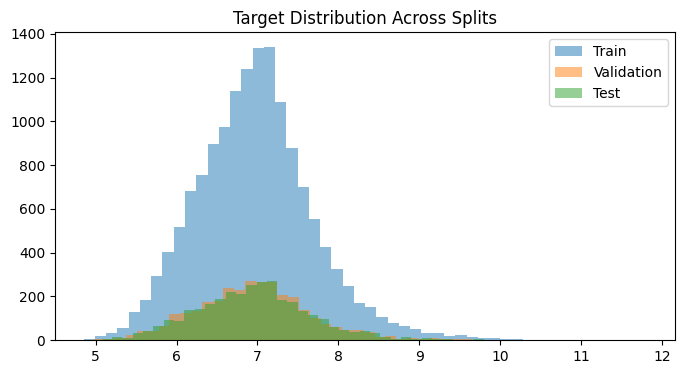

In [ ]:
# Import feature list from model configuration
from src.settings.model_config import MODEL_FEATURES

# 1. Define features and target

# Input features
X = df_model[MODEL_FEATURES]

# Target variable
y = df_model["log_price"]

# 2. Train / Validation / Test split

# First split:
# 70% training
# 30% temporary (validation + test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Second split:
# 15% validation
# 15% test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# 3. Validate dataset shapes
print("============= DATASET SPLITS =============")

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

print()

print(f"y_train: {y_train.shape}")
print(f"y_val:   {y_val.shape}")
print(f"y_test:  {y_test.shape}")


# 4. Validate target distributions
print("\n============= TARGET DISTRIBUTION =============\n")

# Combine distributions into one table
summary = pd.concat([
    y_train.describe().to_frame(name="Train"),
    y_val.describe().to_frame(name="Validation"),
    y_test.describe().to_frame(name="Test")
], axis=1)

print(summary)

# Visualize distributions
plt.figure(figsize=(8,4))

plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Validation")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")

plt.legend()
plt.title("Target Distribution Across Splits")

plt.show()

In [9]:
# Combine describe outputs into one table
summary = pd.concat([
    y_train.describe().to_frame(name="Train"),
    y_val.describe().to_frame(name="Validation"),
    y_test.describe().to_frame(name="Test")
], axis=1)

print(summary)


              Train   Validation         Test
count  15015.000000  3217.000000  3218.000000
mean       6.975443     6.962141     6.964193
std        0.733728     0.729505     0.731168
min        4.852030     4.844187     4.948760
25%        6.496020     6.486161     6.481577
50%        6.957497     6.941190     6.961296
75%        7.387090     7.377759     7.381346
max       11.812786    11.520010    11.326066


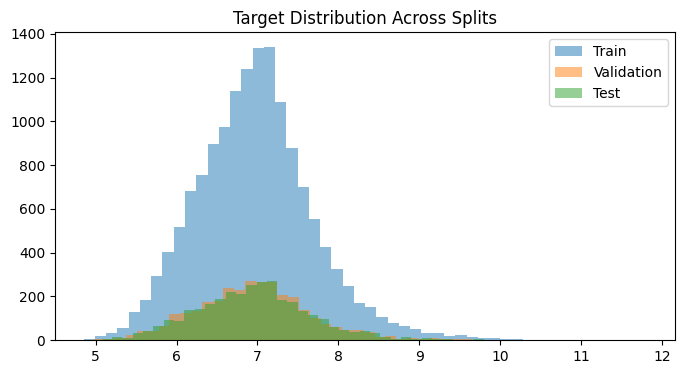

In [4]:
plt.figure(figsize=(8,4))

plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Validation")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")

plt.legend()
plt.title("Target Distribution Across Splits")

plt.show()